In [18]:
import numpy as np
import pandas as pd

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    RepeatVector,
    TimeDistributed,
    Dense
)

In [2]:
import os

%load_ext dotenv
%dotenv

cdsapi_key = os.getenv("CDS-API-KEY")

In [37]:
import xarray as xr

# Geo-chunked surface levels data (optimised for time-series at a single location)
geochunked_sfc_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-002/arco/reanalysis_era5_single_levels/sfc/geoChunked.zarr"

# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    geochunked_sfc_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 63TB
Dimensions:    (time: 758256, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2026-07-01T23:00:00
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables: (12/20)
    blh        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    cbh        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    d2m        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    fdir       (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    fg10       (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    msl        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    ...         ...
    tcc        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    tp         (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    u10        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    u100       (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    v10        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    v100       (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

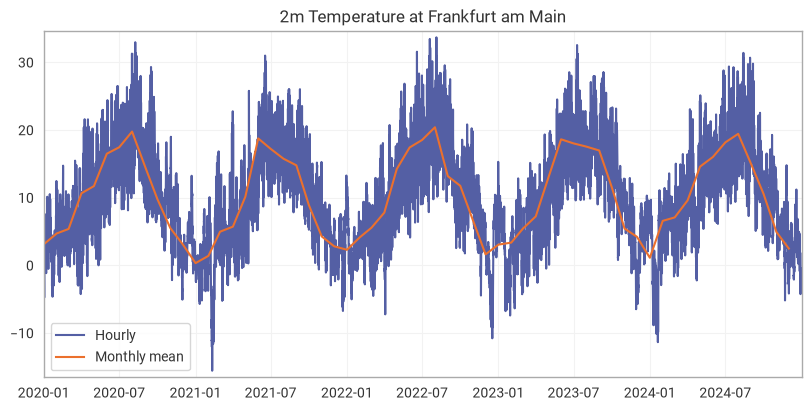

In [40]:
# plot raw data

from earthkit import plots as ekp
from earthkit import transforms as ekt

import warnings
warnings.filterwarnings(
    "ignore",
    message="TimeSeries is an experimental new feature*"
)

# Select variable to plot
variable_name = "t2m"
time = slice("2020-01-01", "2024-12-31")

plot_data_hourly = (
    ds[variable_name]
    .sel(latitude=50.7, longitude=8.41, method="nearest") # Frankfurt
    # .sel(latitude=51.5, longitude=-0.1, method="nearest") # London
    .sel(time=time)
    - 273.15
)
plot_data_monthly = ekt.temporal.monthly_mean(plot_data_hourly)

chart = ekp.TimeSeries()

chart.line(plot_data_hourly, label="Hourly")
chart.line(plot_data_monthly, label="Monthly mean")

chart.title("2m Temperature at Frankfurt am Main")
chart.legend()

chart.show()